In [3]:
f(t, y) = -2*y

y_exact(t) = exp(-2*t)


y_exact (generic function with 1 method)

In [2]:
function euler(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = range(t0, step=h, length=N+1)
    y = zeros(N+1)
    y[1] = y0

    for n in 1:N
        y[n+1] = y[n] + h*f(t[n], y[n])
    end

    return collect(t), y
end


euler (generic function with 1 method)

In [4]:
function rk2(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = range(t0, step=h, length=N+1)
    y = zeros(N+1)
    y[1] = y0

    for n in 1:N
        k1 = f(t[n], y[n])
        k2 = f(t[n] + h/2, y[n] + (h/2)*k1)
        y[n+1] = y[n] + h*k2
    end

    return collect(t), y
end


rk2 (generic function with 1 method)

In [5]:
function rk4(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = range(t0, step=h, length=N+1)
    y = zeros(N+1)
    y[1] = y0

    for n in 1:N
        k1 = f(t[n], y[n])
        k2 = f(t[n] + h/2, y[n] + (h/2)*k1)
        k3 = f(t[n] + h/2, y[n] + (h/2)*k2)
        k4 = f(t[n] + h, y[n] + h*k3)

        y[n+1] = y[n] + (h/6)*(k1 + 2k2 + 2k3 + k4)
    end

    return collect(t), y
end



rk4 (generic function with 1 method)

In [6]:
function max_error(t, y_num)
    y_true = [y_exact(ti) for ti in t]
    return maximum(abs.(y_true .- y_num))
end


function final_error(t, y_num)
    return abs(y_exact(t[end]) - y_num[end])
end

function empirical_order(Eh, Eh2)
    return log(Eh/Eh2) / log(2)
end

empirical_order (generic function with 1 method)

In [7]:
using Printf

t0 = 0.0
y0 = 1.0
T  = 2.0
hs = [0.4, 0.2, 0.1, 0.05]

methods = Dict(
    "Euler" => euler,
    "RK2"   => rk2,
    "RK4"   => rk4
)

for (name, method) in methods
    println("\n" * name)
    println("h        max error        observed order")
    
    errors = Float64[]

    for h in hs
        t, y_num = method(f, t0, y0, T, h)
        E = max_error(t, y_num)
        push!(errors, E)
    end

    for i in eachindex(hs)
        if i == 1
            println(string(hs[i], "    ", errors[i], "    -"))
        else
            p = empirical_order(errors[i-1], errors[i])
            println(string(hs[i], "    ", errors[i], "    ", p))
        end
    end
end



RK4
h        max error        observed order
0.4    0.002404369216111757    -
0.2    0.00010778975179787098    4.4793665297484475
0.1    5.79695385960477e-6    4.216781206288739
0.05    3.3324105608301124e-7    4.120656942447879

Euler
h        max error        observed order
0.4    0.2493289641172216    -
0.2    0.08932896411722158    1.4808505506990945
0.1    0.04019944117144231    1.151952586095202
0.05    0.019201001071442347    1.0659939162002954

RK2
h        max error        observed order
0.4    0.07067103588277845    -
0.2    0.013237788087797797    2.4164569746532627
0.1    0.0028604020285575293    2.2103722445800837
0.05    0.0006615436621095205    2.1123096484362334


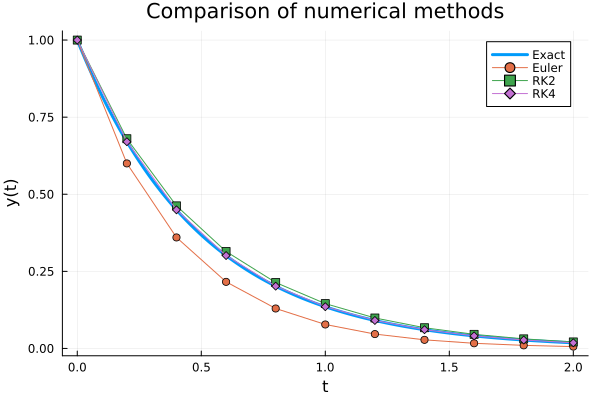

In [8]:
using Plots

h = 0.2
t_e, y_e = euler(f, t0, y0, T, h)
t_rk2, y_rk2 = rk2(f, t0, y0, T, h)
t_rk4, y_rk4 = rk4(f, t0, y0, T, h)

t_exact = 0:0.01:T
y_true = [y_exact(ti) for ti in t_exact]

plot(t_exact, y_true, label="Exact", linewidth=3)
plot!(t_e, y_e, marker=:circle, label="Euler")
plot!(t_rk2, y_rk2, marker=:square, label="RK2")
plot!(t_rk4, y_rk4, marker=:diamond, label="RK4")
xlabel!("t")
ylabel!("y(t)")
title!("Comparison of numerical methods")